<a href="https://colab.research.google.com/github/robertzengcn/cnn_cifar10/blob/master/Stock_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown

In [2]:
import gdown

file_id = "1MqY9yaql1XQbodFSngsHxGbyLdWRhVXj"
url = f"https://drive.google.com/uc?id={file_id}"
output = "AMZN.csv"  # You can rename this as needed

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1MqY9yaql1XQbodFSngsHxGbyLdWRhVXj
To: /content/AMZN.csv
100%|██████████| 445k/445k [00:00<00:00, 107MB/s]


'AMZN.csv'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
data=pd.read_csv("AMZN.csv")



In [4]:
data.sample(5)

,Date,Open,High,Low,Close,Adj Close,Volume
4864,2016-09-13,38.438499,38.494499,37.952499,38.050499,38.050499,62344000
4548,2015-06-12,21.562500,21.618000,21.413000,21.496000,21.496000,41088000
146,1997-12-11,0.219792,0.241667,0.219792,0.234375,0.234375,100296000
2306,2006-07-17,1.639500,1.696500,1.639500,1.683500,1.683500,143946000
4151,2013-11-12,17.649500,17.774000,17.364000,17.476500,17.476500,46862000


In [5]:
data.shape

(6516, 7)

In [6]:
data=data[['Date','Close']]
data

,Date,Close
0,1997-05-15,0.097917
1,1997-05-16,0.086458
2,1997-05-19,0.085417
3,1997-05-20,0.081771
4,1997-05-21,0.071354
...,...,...
6511,2023-03-30,102.000000
6512,2023-03-31,103.290001
6513,2023-04-03,102.410004
6514,2023-04-04,103.949997


In [7]:
device='cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

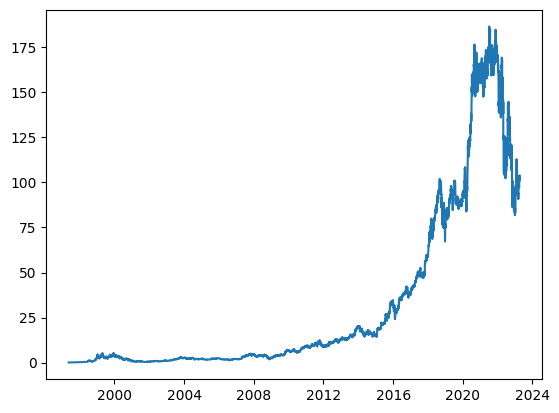

In [8]:
data['Date']=pd.to_datetime(data['Date'])
plt.plot(data['Date'],data['Close'])

In [9]:
from copy import deepcopy as dc
def prepare_dataframe_for_lstm(df,n_steps):
  df=dc(df)
  df['Date']=pd.to_datetime(df['Date'])
  df.set_index('Date',inplace=True)

  for i in range(1,n_steps+1):
    df[f'Close(t-{i})']=df['Close'].shift(i)
  df.dropna(inplace=True)
  return df

lookback=7
shifted_df=prepare_dataframe_for_lstm(data,lookback)
shifted_df


,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
1997-05-27,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1997-05-28,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
1997-05-29,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
1997-05-30,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
1997-06-02,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354
...,...,...,...,...,...,...,...,...
2023-03-30,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997,100.610001
2023-03-31,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997
2023-04-03,102.410004,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999


In [10]:
shifted_df_as_np=shifted_df.to_numpy()
shifted_df_as_np

array([[7.91670000e-02, 7.50000000e-02, 6.97920000e-02, ...,
        8.54170000e-02, 8.64580000e-02, 9.79170000e-02],
       [7.65630000e-02, 7.91670000e-02, 7.50000000e-02, ...,
        8.17710000e-02, 8.54170000e-02, 8.64580000e-02],
       [7.52600000e-02, 7.65630000e-02, 7.91670000e-02, ...,
        7.13540000e-02, 8.17710000e-02, 8.54170000e-02],
       ...,
       [1.02410004e+02, 1.03290001e+02, 1.02000000e+02, ...,
        9.80400010e+01, 9.81299970e+01, 9.87099990e+01],
       [1.03949997e+02, 1.02410004e+02, 1.03290001e+02, ...,
        9.72399980e+01, 9.80400010e+01, 9.81299970e+01],
       [1.01099998e+02, 1.03949997e+02, 1.02410004e+02, ...,
        1.00250000e+02, 9.72399980e+01, 9.80400010e+01]])

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(-1,1))
shifted_df_as_np=scaler.fit_transform(shifted_df_as_np)
shifted_df_as_np

array([[-0.99991063, -0.99995531, -1.        , ..., -0.99983244,
        -0.99982128, -0.99969839],
       [-0.99993855, -0.99991063, -0.99994415, ..., -0.99987154,
        -0.99983244, -0.99982128],
       [-0.99995253, -0.99993855, -0.99989946, ..., -0.99998325,
        -0.99987154, -0.99983244],
       ...,
       [ 0.09747299,  0.10690997,  0.09308121, ...,  0.0506149 ,
         0.05158   ,  0.05779984],
       [ 0.11398769,  0.09747299,  0.10691495, ...,  0.04203581,
         0.0506149 ,  0.05158   ],
       [ 0.08342464,  0.11398769,  0.09747802, ...,  0.07431453,
         0.04203581,  0.0506149 ]])

In [12]:
X=shifted_df_as_np[:,1:]
y=shifted_df_as_np[:,0]
X.shape,y.shape

((6509, 7), (6509,))

In [13]:
X=dc(np.flip(X,axis=-1))
X

array([[-0.99969839, -0.99982128, -0.99983244, ..., -0.99998325,
        -1.        , -0.99995531],
       [-0.99982128, -0.99983244, -0.99987154, ..., -1.        ,
        -0.99994415, -0.99991063],
       [-0.99983244, -0.99987154, -0.99998325, ..., -0.99994415,
        -0.99989946, -0.99993855],
       ...,
       [ 0.05779984,  0.05158   ,  0.0506149 , ...,  0.07431453,
         0.09308121,  0.10690997],
       [ 0.05158   ,  0.0506149 ,  0.04203581, ...,  0.09308121,
         0.10691495,  0.09747299],
       [ 0.0506149 ,  0.04203581,  0.07431453, ...,  0.10691495,
         0.09747802,  0.11398769]])

In [14]:
X.shape

(6509, 7)

In [15]:
split_index=int(len(X)*0.95)
split_index

6183

In [16]:
X_train=X[:split_index]
X_test=X[split_index:]
y_train=y[:split_index]
y_test=y[split_index:]

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6183, 7), (326, 7), (6183,), (326,))

In [17]:
X_train=X_train.reshape((-1,lookback,1))
X_test=X_test.reshape((-1,lookback,1))
y_train=y_train.reshape((-1,1))
y_test=y_test.reshape((-1,1))
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6183, 7, 1), (326, 7, 1), (6183, 1), (326, 1))

In [18]:
X_train=torch.tensor(X_train).float()
y_train=torch.tensor(y_train).float()
X_test=torch.tensor(X_test).float()
y_test=torch.tensor(y_test).float()
X_train.shape,X_test.shape,y_train.shape,y_test.shape

(torch.Size([6183, 7, 1]),
 torch.Size([326, 7, 1]),
 torch.Size([6183, 1]),
 torch.Size([326, 1]))

In [19]:
from torch.utils.data import Dataset
class TimeSeriesDataset(Dataset):
  def __init__(self,X,y):
    self.X=X
    self.y=y
  def __len__(self):
    return len(self.X)
  def __getitem__(self, i):
    return self.X[i],self.y[i]

train_dataset=TimeSeriesDataset(X_train,y_train)
test_dataset=TimeSeriesDataset(X_test,y_test)

In [20]:
train_dataset

In [21]:
from torch.utils.data import DataLoader
batch_size=16
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [22]:
for _,batch in enumerate(train_loader):
  x_batch,y_batch=batch[0].to(device),batch[1].to(device)
  print(x_batch.shape,y_batch.shape)
  break

torch.Size([16, 7, 1]) torch.Size([16, 1])


In [23]:
class LSTM(nn.Module):
  def __init__(self,input_size,hidden_size,num_stacked_layers):
    super().__init__()
    self.hidden_size=hidden_size
    self.num_stacked_layers=num_stacked_layers
    self.lstm=nn.LSTM(input_size,hidden_size,num_stacked_layers,batch_first=True)
    self.fc=nn.Linear(hidden_size,1)

  def forward(self,x):
    batch_size=x.size(0)
    h0=torch.zeros(self.num_stacked_layers,batch_size,self.hidden_size).to(device)
    c0=torch.zeros(self.num_stacked_layers,batch_size,self.hidden_size).to(device)
    out,_=self.lstm(x,(h0,c0))
    out=self.fc(out[:,-1,:])
    return out
model=LSTM(1,4,1)
model.to(device)
model


LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [37]:
def train_one_epoch():
  model.train(True)
  print(f"Epoch {epoch+1}")
  running_loss=0.0

  for batch_index, batch in enumerate(train_loader):
    x_batch,y_batch=batch[0].to(device),batch[1].to(device)
    output=model(x_batch)
    loss=loss_function(output,y_batch)
    running_loss+=loss.item()
    # print(f"running loss {running_loss}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch_index % 100==99:
      avg_loss_across_batches=running_loss/100
      print('Batch {0},Loss:{1:.4f}'.format(batch_index+1,avg_loss_across_batches))
      running_loss=0.0
  print()


In [35]:
def validate_one_epoch():
  model.train(False)
  running_loss=0.0
  for batch_index, batch in enumerate(test_loader):
    x_batch,y_batch=batch[0].to(device),batch[1].to(device)
    with torch.no_grad():
      output=model(x_batch)
      loss=loss_function(output,y_batch)
      running_loss+=loss.item()
  avg_loss_across_batches=running_loss/len(test_loader)

  print('Val loss: {0:.4f}'.format(avg_loss_across_batches))
  print('****************************************************')
  print()


In [38]:
learning_rate=0.001
num_epochs=10
loss_function=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

for epoch in range(num_epochs):
  train_one_epoch()
  validate_one_epoch()


Epoch 1
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0018
****************************************************

Epoch 2
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0017
****************************************************

Epoch 3
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0016
****************************************************

Epoch 4
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0015
****************************************************

Epoch 5
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0016
****************************************************

Epoch 6
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0015
****************************************************

Epoch 7
Batch 100,Loss:0.0001
Batch 200,Loss:0.0001
Batch 300,Loss:0.0001

Val loss: 0.0016
********************************

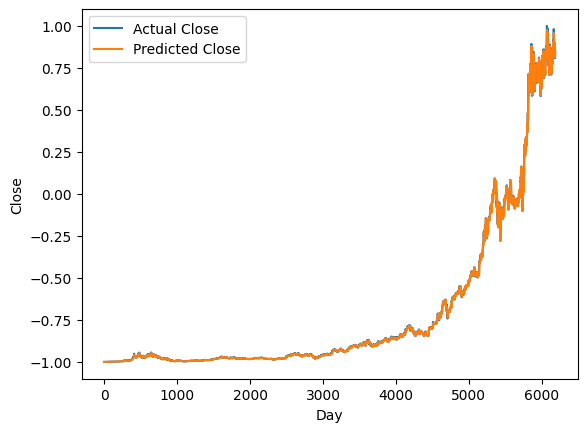

In [39]:
with torch.no_grad():
  predicted=model(X_train.to(device)).to('cpu').numpy()
plt.plot(y_train,label='Actual Close')
plt.plot(predicted,label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [53]:
train_predictions=predicted.flatten()

dummies=np.zeros((X_train.shape[0],lookback+1))

dummies[:,0]=train_predictions

dummies=scaler.inverse_transform(dummies)


train_predictions=dc(dummies[:,0])
# train_predictions
train_predictions





array([5.71044360e-02, 5.82605256e-02, 5.75935508e-02, ...,
       1.69582371e+02, 1.69097536e+02, 1.72710705e+02])

In [56]:
dummies=np.zeros((X_train.shape[0],lookback+1))
dummies[:,0]=y_train.flatten()
dumies=scaler.inverse_transform(dummies)
new_y_train=dc(dumies[:,0])
new_y_train

/tmp/ipython-input-3382918379.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dummies[:,0]=y_train.flatten()


array([7.91646265e-02, 7.65634249e-02, 7.52572660e-02, ...,
       1.69091505e+02, 1.73315001e+02, 1.68871003e+02])

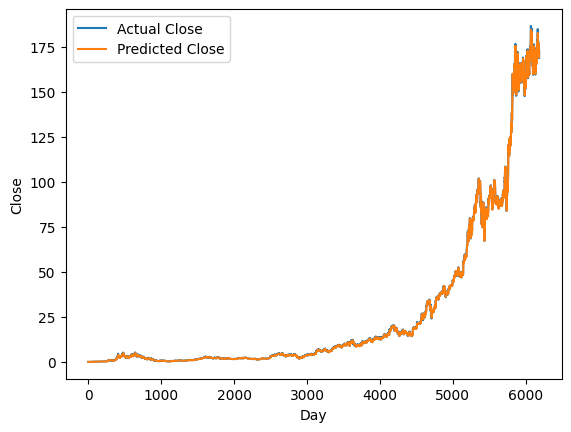

In [58]:
plt.plot(new_y_train,label='Actual Close')
plt.plot(train_predictions,label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [62]:
test_predictions=model(X_test.to(device)).detach().cpu().numpy().flatten()
dumies=np.zeros((X_test.shape[0],lookback+1))
dumies[:,0]=test_predictions
dumies=scaler.inverse_transform(dummies)
test_predictions=dc(dummies[:,0])
test_predictions

array([170.01749949, 167.07899763, 170.41700626, 171.03700377,
       171.0684961 , 169.66949429, 170.66099675, 169.20100565,
       168.64449858, 166.71699707, 170.40449492, 167.52200227,
       164.35699578, 163.25399737, 162.55400179, 161.48599177,
       165.36199892, 165.20699954, 161.21400501, 162.13799851,
       158.91749416, 156.29899568, 151.66749509, 142.64300408,
       144.54400445, 139.98599336, 138.87249844, 139.63749627,
       143.97799855, 149.57350001, 151.19349835, 150.61250219,
       138.84550541, 157.63949825, 157.93550165, 161.41349717,
       161.18949925, 159.003495  , 153.29350176, 155.1670061 ,
       156.51049894, 158.10049453, 154.6524962 , 152.60149876,
       150.19749381, 144.82699629, 151.35800212, 153.78849709,
       153.56300403, 151.14199678, 152.05250627, 147.89849848,
       145.64100565, 137.45300383, 136.01449488, 139.27900567,
       146.81750468, 145.52450739, 141.8529947 , 147.36650272,
       153.10400311, 157.23899657, 161.25050521, 161.49

In [63]:
dummies=np.zeros((X_test.shape[0],lookback+1))
dummies[:,0]=y_test.flatten()
dummies=scaler.inverse_transform(dummies)

new_y_test=dc(dummies[:,0])
new_y_test

/tmp/ipython-input-240147068.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dummies[:,0]=y_test.flatten()


array([170.01749949, 167.07899763, 170.41700626, 171.03700377,
       171.0684961 , 169.66949429, 170.66099675, 169.20100565,
       168.64449858, 166.71699707, 170.40449492, 167.52200227,
       164.35699578, 163.25399737, 162.55400179, 161.48599177,
       165.36199892, 165.20699954, 161.21400501, 162.13799851,
       158.91749416, 156.29899568, 151.66749509, 142.64300408,
       144.54400445, 139.98599336, 138.87249844, 139.63749627,
       143.97799855, 149.57350001, 151.19349835, 150.61250219,
       138.84550541, 157.63949825, 157.93550165, 161.41349717,
       161.18949925, 159.003495  , 153.29350176, 155.1670061 ,
       156.51049894, 158.10049453, 154.6524962 , 152.60149876,
       150.19749381, 144.82699629, 151.35800212, 153.78849709,
       153.56300403, 151.14199678, 152.05250627, 147.89849848,
       145.64100565, 137.45300383, 136.01449488, 139.27900567,
       146.81750468, 145.52450739, 141.8529947 , 147.36650272,
       153.10400311, 157.23899657, 161.25050521, 161.49

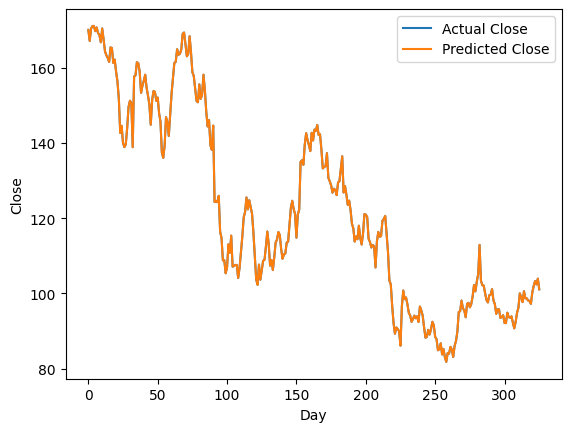

In [65]:
plt.plot(new_y_test,label='Actual Close')
plt.plot(test_predictions,label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()